# 02 — Cleaning & Feature Engineering
Turns the raw encounters into one model-ready table, applying the decisions from the Step 1 audit.

**Output:** `data/processed/model_table.parquet`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW, PROC, FIG = Path("data/raw"), Path("data/processed"), Path("figures")
PROC.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW / "diabetic_data.csv", na_values=["?"], keep_default_na=False, low_memory=False)
print("Raw:", df.shape)

Raw: (101766, 50)


## 1. Rows: remove leakage and invalid records

In [2]:
EXCLUDE_DISCHARGE = [11, 13, 14, 19, 20, 21]   # expired or hospice
before = len(df)
df = df[~df["discharge_disposition_id"].isin(EXCLUDE_DISCHARGE)]
df = df[df["gender"] != "Unknown/Invalid"]
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
print(f"Removed {before - len(df):,} rows -> {len(df):,} encounters, readmission rate {df['readmit_30'].mean():.1%}")

Removed 2,426 rows -> 99,340 encounters, readmission rate 11.4%


## 2. Columns: drop mostly-missing and constant columns

In [3]:
constant = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
drop_cols = ["weight", "encounter_id", "readmitted"] + constant
df = df.drop(columns=drop_cols)
print("Dropped:", drop_cols)

Dropped: ['weight', 'encounter_id', 'readmitted', 'examide', 'citoglipton']


## 3. Missing categories become 'Unknown'

In [4]:
for col in ["race", "payer_code", "medical_specialty"]:
    df[col] = df[col].fillna("Unknown")

# keep the 10 most common specialties, group the rest
top_spec = df["medical_specialty"].value_counts().index[:11]   # includes 'Unknown'
df["medical_specialty"] = df["medical_specialty"].where(df["medical_specialty"].isin(top_spec), "Other")
df["medical_specialty"].value_counts()

medical_specialty
Unknown                       48614
InternalMedicine              14237
Emergency/Trauma               7419
Other                          7345
Family/GeneralPractice         7252
Cardiology                     5278
Surgery-General                3059
Nephrology                     1539
Orthopedics                    1392
Orthopedics-Reconstructive     1230
Radiologist                    1121
Pulmonology                     854
Name: count, dtype: int64

## 4. Age as a number (bracket midpoint)

In [5]:
df["age_num"] = df["age"].str.extract(r"\[(\d+)-").astype(int)[0] + 5
df = df.drop(columns="age")
df["age_num"].value_counts().sort_index()

age_num
5       160
15      690
25     1649
35     3764
45     9607
55    17060
65    22058
75    25329
85    16434
95     2589
Name: count, dtype: int64

## 5. Diagnosis codes → clinical groups
ICD-9 codes are grouped into the categories used in the original study of this dataset (Strack et al., 2014).

In [6]:
def icd9_group(code):
    if pd.isna(code):
        return "Missing"
    code = str(code)
    if code.startswith(("V", "E")):
        return "Other"
    if code.startswith("250"):
        return "Diabetes"
    x = float(code)
    if 390 <= x <= 459 or int(x) == 785: return "Circulatory"
    if 460 <= x <= 519 or int(x) == 786: return "Respiratory"
    if 520 <= x <= 579 or int(x) == 787: return "Digestive"
    if 800 <= x <= 999:                   return "Injury"
    if 710 <= x <= 739:                   return "Musculoskeletal"
    if 580 <= x <= 629 or int(x) == 788: return "Genitourinary"
    if 140 <= x <= 239:                   return "Neoplasms"
    return "Other"

for d in ["diag_1", "diag_2", "diag_3"]:
    df[f"{d}_group"] = df[d].map(icd9_group)
df = df.drop(columns=["diag_1", "diag_2", "diag_3"])
df["diag_1_group"].value_counts()

diag_1_group
Circulatory        29680
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6851
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Missing               20
Name: count, dtype: int64

## 6. Prior utilisation: totals, caps and log transforms

In [7]:
visits = ["number_outpatient", "number_emergency", "number_inpatient"]
df["total_prior_visits"] = df[visits].sum(axis=1)
for c in visits + ["total_prior_visits"]:
    df[f"{c}_log"] = np.log1p(df[c].clip(upper=df[c].quantile(0.999)))
df[[f"{c}_log" for c in visits]].describe().round(2)

,number_outpatient_log,number_emergency_log,number_inpatient_log
count,99340.00,99340.00,99340.00
mean,0.17,0.10,0.32
std,0.43,0.31,0.51
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,0.00,0.00,0.69
max,2.71,2.40,2.48


## 7. Medications: counts of active and changed drugs

In [8]:
MED_VALUES = {"No", "Steady", "Up", "Down"}
med_cols = [c for c in df.columns if set(df[c].dropna().unique()) <= MED_VALUES]
print(f"{len(med_cols)} medication columns")

df["n_meds_active"]  = (df[med_cols] != "No").sum(axis=1)
df["n_meds_changed"] = df[med_cols].isin(["Up", "Down"]).sum(axis=1)
df["insulin_status"] = df["insulin"] if "insulin" in df else "No"

# keep only medications used in at least 1% of encounters as individual flags
common = [c for c in med_cols if (df[c] != "No").mean() >= 0.01 and c != "insulin"]
for c in common:
    df[f"med_{c}"] = (df[c] != "No").astype(int)
df = df.drop(columns=med_cols)
print("Kept individual flags for:", common)

21 medication columns
Kept individual flags for: ['metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']


## 8. Lab tests and binary flags

In [9]:
df["a1c_tested"]     = (df["A1Cresult"] != "None").astype(int)
df["glucose_tested"] = (df["max_glu_serum"] != "None").astype(int)
df["med_change"]     = (df["change"] == "Ch").astype(int)
df["on_diabetes_med"] = (df["diabetesMed"] == "Yes").astype(int)
df["male"]           = (df["gender"] == "Male").astype(int)
df = df.drop(columns=["change", "diabetesMed", "gender"])

## 9. ID codes as categories (rare codes grouped)

In [10]:
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    s = df[col].astype(str)
    share = s.value_counts(normalize=True)
    df[col] = s.where(s.isin(share[share >= 0.01].index), "Other")
    print(col, "->", df[col].nunique(), "categories")

admission_type_id -> 6 categories
discharge_disposition_id -> 8 categories
admission_source_id -> 7 categories


## 10. Final table

In [11]:
CAT_COLS = ["race", "payer_code", "medical_specialty", "admission_type_id",
            "discharge_disposition_id", "admission_source_id", "A1Cresult", "max_glu_serum",
            "insulin_status", "diag_1_group", "diag_2_group", "diag_3_group"]
for c in CAT_COLS:
    df[c] = df[c].astype("category")

print("Shape:", df.shape)
print("Readmission rate:", f"{df['readmit_30'].mean():.1%}")
print("Missing values left:", int(df.isna().sum().sum()))
df.dtypes.value_counts()

Shape: (99340, 42)
Readmission rate: 11.4%
Missing values left: 0


int64       26
float64      4
category     3
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

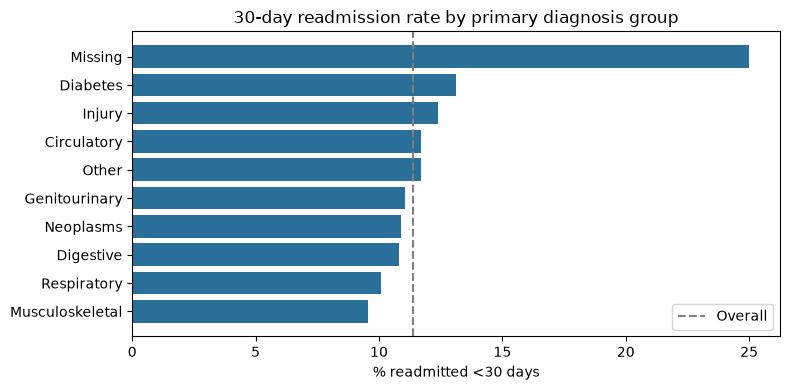

,encounters,readmit_rate
diag_1_group,,
Musculoskeletal,4935,9.5
Respiratory,13934,10.1
Digestive,9333,10.8
Neoplasms,3131,10.9
Genitourinary,5002,11.0
Other,17793,11.7
Circulatory,29680,11.7
Injury,6851,12.4
Diabetes,8661,13.1


In [12]:
rate = (df.groupby("diag_1_group", observed=True)["readmit_30"]
          .agg(encounters="size", readmit_rate="mean")
          .sort_values("readmit_rate"))
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(rate.index, rate["readmit_rate"] * 100, color="#2a6f97")
ax.axvline(df["readmit_30"].mean() * 100, color="grey", ls="--", label="Overall")
ax.set_xlabel("% readmitted <30 days")
ax.set_title("30-day readmission rate by primary diagnosis group")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02_readmit_by_diagnosis.png", dpi=150)
plt.show()
rate.assign(readmit_rate=(rate.readmit_rate * 100).round(1))

In [13]:
df.to_parquet(PROC / "model_table.parquet", index=False)
print("Saved", PROC / "model_table.parquet")

Saved data\processed\model_table.parquet


## 11. Summary
- **Final encounters / features:** 99,340 encounters and 40 features (42 columns including `patient_nbr` and the target). No missing values remain.
- **Readmission rate after cleaning:** 11.4%.
- **Primary diagnosis groups with highest readmission:** Diabetes (13.1%) and Injury (12.4%). Musculoskeletal (9.5%) and Respiratory (10.1%) are lowest. "Missing" shows 25%, but on only 20 encounters, so it is noise, not signal.
- **Medication flags kept:** metformin, repaglinide, glimepiride, glipizide, glyburide, pioglitazone and rosiglitazone (used in at least 1% of encounters). Insulin is kept as its own four-level category. The 21 medication columns are also summarised as counts of active and changed drugs.